<a href="https://colab.research.google.com/github/isabelle-sauget/democracy-econ_growth_analysis/blob/main/factorial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

In [ ]:
df_etichetat = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FA.csv")
df_etichetat.head()
df_etichetat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country_name        160 non-null    object 
 1   iso_code            160 non-null    object 
 2   year                160 non-null    int64  
 3   v2psbars_osp        160 non-null    float64
 4   v2exrescon_osp      160 non-null    float64
 5   v2exbribe_osp       160 non-null    float64
 6   v2lgotovst_osp      160 non-null    float64
 7   v2dlcountr_osp      160 non-null    float64
 8   v2juhcind_osp       160 non-null    float64
 9   v2jucorrdc_osp      160 non-null    float64
 10  v2jucomp_osp        160 non-null    float64
 11  v2clrspct_osp       160 non-null    float64
 12  v2clacjstw_osp      160 non-null    float64
 13  v2pepwrgen_osp      160 non-null    float64
 14  v2stcritrecadm_osp  160 non-null    float64
 15  v2cseeorgs_osp      160 non-null    float64
 16  v2csanti

In [ ]:
df_etichetat[df_etichetat['country_name'] == "Romania"]

,country_name,iso_code,year,v2psbars_osp,v2exrescon_osp,v2exbribe_osp,v2lgotovst_osp,v2dlcountr_osp,v2juhcind_osp,v2jucorrdc_osp,...,v2cacamps_osp,v2caviol_osp,v2caautmob_osp,v2capolit_osp,v2cacritic_osp,v2smgovcapsec_osp,v2smpardom_osp,v2smfordom_osp,v2smpolsoc_osp,GDPPC
149,Romania,ROU,2024,3.809,2.292,2.718,1.983,1.715,1.254,2.439,...,3.878,0.856,1.548,1.159,3.505,2.06,1.834,1.29,0.441,40504.000295


In [ ]:
valori_romania = df_etichetat[df_etichetat['country_name'] == "Romania"]
valori_romania.to_excel("Romania_data.xlsx", index=False)

# O prima incercare de a vedea cum se formeaza factorii in AF


In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=b046d69e5a478317ee1c7a1927e8be2a2a2d2750331397e32bff40de2f456c9d
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:

df = df_etichetat.iloc[:,:-1]
df = df.drop(df.columns[0:3], axis=1)
#axis=1 sunt coloanele, iar axis=0 sunt randurile
df.head()

,v2psbars_osp,v2exrescon_osp,v2exbribe_osp,v2lgotovst_osp,v2dlcountr_osp,v2juhcind_osp,v2jucorrdc_osp,v2jucomp_osp,v2clrspct_osp,v2clacjstw_osp,...,v2pehealth_osp,v2cacamps_osp,v2caviol_osp,v2caautmob_osp,v2capolit_osp,v2cacritic_osp,v2smgovcapsec_osp,v2smpardom_osp,v2smfordom_osp,v2smpolsoc_osp
0,3.541,1.726,1.448,1.015,1.344,2.261,2.499,1.162,1.733,1.634,...,0.905,3.788,3.320,0.615,1.403,2.829,2.180,0.816,2.981,0.332
1,3.873,3.141,2.697,2.359,2.435,2.675,3.372,3.152,2.559,3.192,...,2.416,2.049,1.436,0.096,2.103,1.346,1.565,2.447,3.030,1.187
2,3.960,3.202,3.948,3.688,3.246,3.753,3.639,3.658,3.738,3.749,...,3.508,1.715,0.620,0.018,2.002,3.418,3.132,3.192,2.786,1.751
3,3.947,3.677,3.846,3.250,3.755,3.420,3.526,3.685,3.919,3.880,...,3.826,1.023,0.137,0.043,2.618,2.698,3.051,2.994,3.896,0.604
4,3.914,2.352,1.032,3.075,2.487,3.001,1.239,3.096,1.145,2.750,...,2.012,1.861,1.857,0.041,2.529,3.632,1.639,2.093,3.460,0.446


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


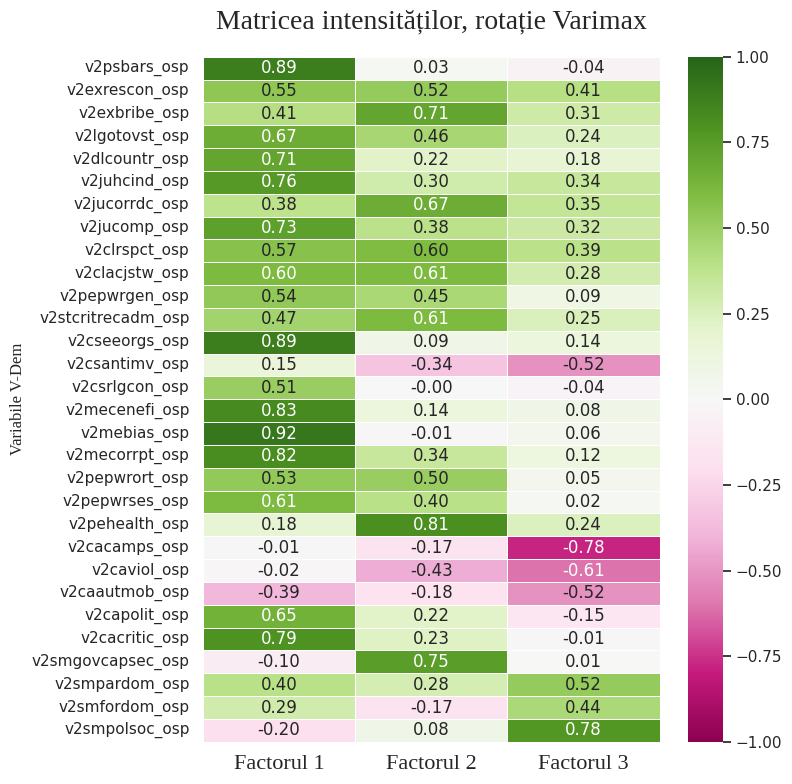

In [ ]:

import seaborn as sns
from factor_analyzer import FactorAnalyzer


sns.set_theme(style="white")



fa = FactorAnalyzer(n_factors=3, rotation='varimax', method='minres')
fa.fit(df)

#matricea ponderilor
loadings = pd.DataFrame(
    fa.loadings_,
    columns=['Factorul 1', 'Factorul 2', 'Factorul 3'],
    index=df.columns
)


plt.figure(figsize=(8,8))
sns.heatmap(loadings,
            annot=True,
            cmap='PiYG',
            center=0,
            fmt=".2f",
            vmin=-1, vmax=1,
            linewidths=.5)

plt.title('Matricea intensităților, rotație Varimax', fontsize=20, pad=20, fontname="Liberation Serif")
plt.ylabel('Variabile V-Dem', fontname="Liberation Serif")
plt.xticks(fontname="Liberation Serif", fontsize=16)
plt.tight_layout()
plt.savefig("loadings.png", dpi=300)
plt.show()


# Statistici descriptive

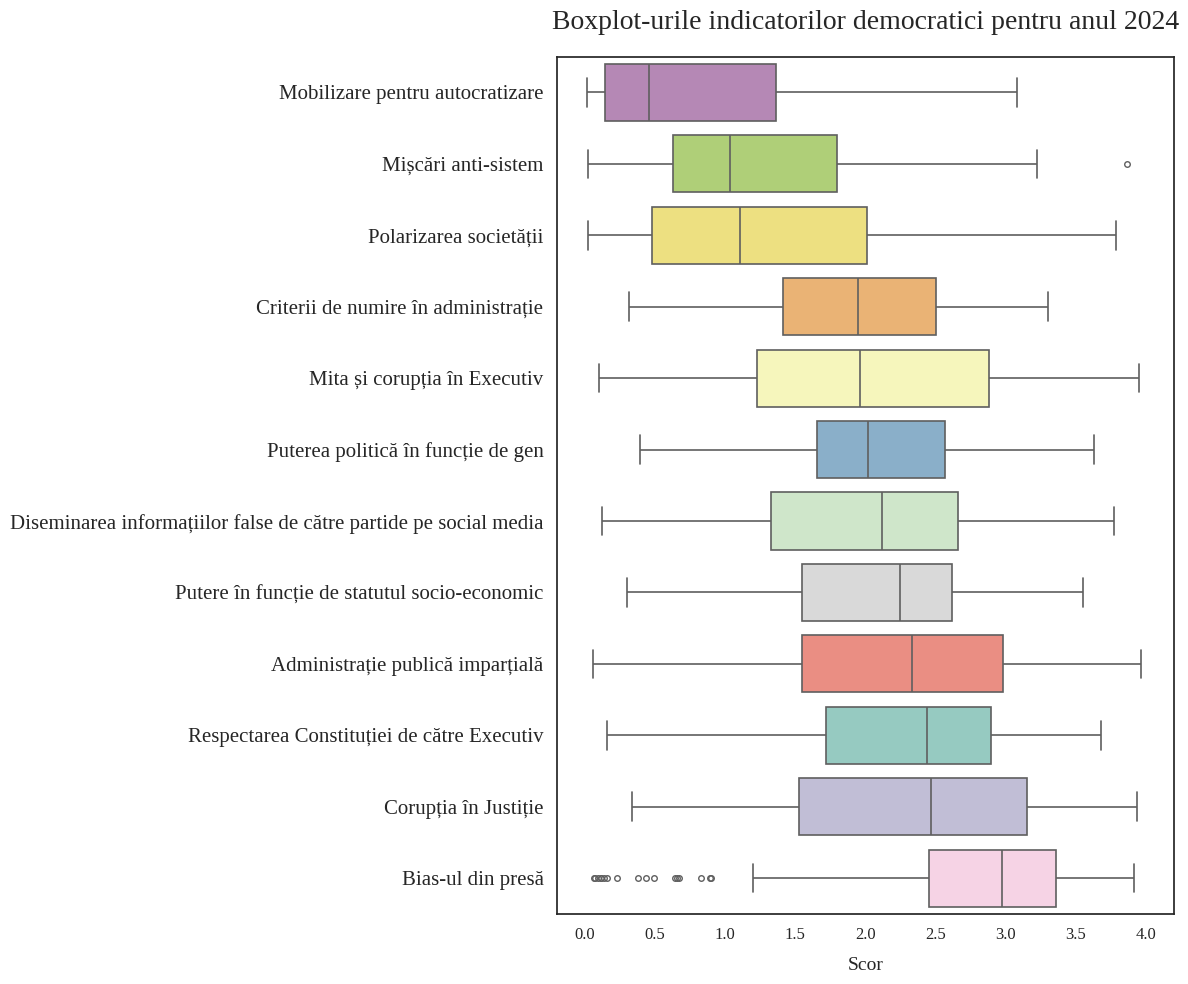

In [ ]:
sns.set_theme(style="white")

coloane = [
    'v2exrescon_osp', 'v2exbribe_osp', 'v2jucorrdc_osp',
    'v2clrspct_osp', 'v2pepwrgen_osp', 'v2stcritrecadm_osp',
    'v2csantimv_osp','v2mebias_osp','v2pepwrses_osp',
    'v2caautmob_osp','v2smpardom_osp','v2smpolsoc_osp'
]

dictionar_nume = {
    'v2exrescon_osp': 'Respectarea Constituției de către Executiv',
    'v2exbribe_osp': 'Mita și corupția în Executiv',
    'v2jucorrdc_osp': 'Corupția în Justiție',
    'v2clrspct_osp': 'Administrație publică imparțială',
    'v2pepwrgen_osp': 'Puterea politică în funcție de gen',
    'v2stcritrecadm_osp': 'Criterii de numire în administrație',
    'v2csantimv_osp': 'Mișcări anti-sistem',
    'v2mebias_osp': 'Bias-ul din presă',
    'v2pepwrses_osp': 'Putere în funcție de statutul socio-economic',
    'v2caautmob_osp': 'Mobilizare pentru autocratizare',
    'v2smpardom_osp': 'Diseminarea informațiilor false de către partide pe social media',
    'v2smpolsoc_osp': 'Polarizarea societății'
}


df_grafic = df[coloane].rename(columns=dictionar_nume)
ordine = df_grafic.median().sort_values().index

#inaltimea e a doua valoare
plt.figure(figsize=(12, 10))
ax = sns.boxplot(
    data=df_grafic,
    orient="h",
    palette="Set3",
    linewidth=1.2,
    fliersize=4, # dimens outliers
    order=ordine
)
plt.xticks(fontsize=12,fontname="Liberation Serif")
plt.yticks(fontsize=15,fontname="Liberation Serif")
plt.title("Boxplot-urile indicatorilor democratici pentru anul 2024", fontsize=20, pad=20,fontname="Liberation Serif")
plt.xlabel("Scor", fontsize=14, labelpad=10,fontname="Liberation Serif")
#plt.ylabel("Indicatori V-Dem", fontsize=14)
plt.xlim(-0.2, 4.2)
plt.tight_layout()

plt.savefig("boxplot_vdem.png", dpi=300)
plt.show()

# Identificarea outlierilor

In [ ]:
def gaseste_outlieri(df, coloana):

    Q1 = df[coloana].quantile(0.25)
    Q3 = df[coloana].quantile(0.75)
    IQR = Q3 - Q1

    limita_inf = Q1 - 1.5 * IQR
    limita_sup = Q3 + 1.5 * IQR

    outlieri = df[(df[coloana] < limita_inf) | (df[coloana] > limita_sup)]
    #filtrarea randurilor
    return outlieri

print("Tari outlier pentru Media bias:")
print(gaseste_outlieri(df_etichetat, 'v2mebias_osp')[['country_name', 'v2mebias_osp']],"\n")
print("Tari outlier pentru Bariere in formarea unui partid:")
print(gaseste_outlieri(df_etichetat, 'v2psbars_osp')[['country_name', 'v2psbars_osp']],"\n")
print("Tari outlier pentru Implicarea in ONG-uri:")
print(gaseste_outlieri(df_etichetat, 'v2capolit_osp')[['country_name', 'v2capolit_osp']],"\n")


Tari outlier pentru Media bias:
             country_name  v2mebias_osp
7                  Russia         0.661
23                Vietnam         0.230
41              Nicaragua         0.118
76                  Qatar         0.162
87             Azerbaijan         0.673
88                Belarus         0.097
91                  China         0.138
103                  Laos         0.074
108                Rwanda         0.644
111              Eswatini         0.376
112            Tajikistan         0.494
115          Turkmenistan         0.117
116            Uzbekistan         0.892
128     Equatorial Guinea         0.902
147                  Oman         0.827
151          Saudi Arabia         0.436
158  United Arab Emirates         0.066 

Tari outlier pentru Bariere in formarea unui partid:
             country_name  v2psbars_osp
23                Vietnam         0.212
41              Nicaragua         0.811
76                  Qatar         0.053
91                  China        

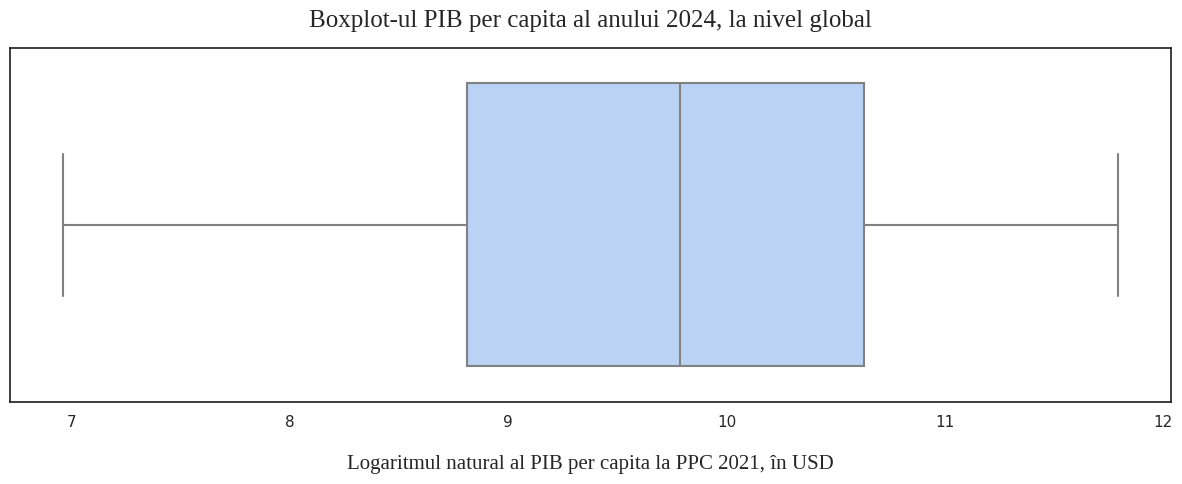

In [ ]:
#boxplot pib
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FA.csv")
df['log_GDPPC'] = np.log(df['GDPPC'])

sns.set_theme(style="white")

plt.figure(figsize=(12,5))
sns.boxplot(
    x=df['log_GDPPC'],
    color="#b1d1fc",
    linewidth=1.5,
    fliersize=6,
    flierprops=dict(marker='o', markerfacecolor='black', alpha=0.6)
    )
plt.title("Boxplot-ul PIB per capita al anului 2024, la nivel global",fontname="Liberation Serif", fontsize=18, pad=15)
plt.xlabel("Logaritmul natural al PIB per capita la PPC 2021, în USD",fontsize=15, labelpad=18,fontname="Liberation Serif")
plt.tight_layout()
plt.savefig("boxplot_pib.png",dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
# schimb ordinea coloanelor log(PIB) cu PIB
cols = list(df.columns)
cols[-2], cols[-1] = 'log_GDPPC', 'GDPPC'
df = df[cols]
display(df.head())

,country_name,iso_code,year,v2psbars_osp,v2exrescon_osp,v2exbribe_osp,v2lgotovst_osp,v2dlcountr_osp,v2juhcind_osp,v2jucorrdc_osp,...,v2caviol_osp,v2caautmob_osp,v2capolit_osp,v2cacritic_osp,v2smgovcapsec_osp,v2smpardom_osp,v2smfordom_osp,v2smpolsoc_osp,log_GDPPC,GDPPC
0,Mexico,MEX,2024,3.541,1.726,1.448,1.015,1.344,2.261,2.499,...,3.320,0.615,1.403,2.829,2.180,0.816,2.981,0.332,10.000597,22039.628702
1,Suriname,SUR,2024,3.873,3.141,2.697,2.359,2.435,2.675,3.372,...,1.436,0.096,2.103,1.346,1.565,2.447,3.030,1.187,9.861577,19179.101832
2,Sweden,SWE,2024,3.960,3.202,3.948,3.688,3.246,3.753,3.639,...,0.620,0.018,2.002,3.418,3.132,3.192,2.786,1.751,11.050556,62978.939046
3,Switzerland,CHE,2024,3.947,3.677,3.846,3.250,3.755,3.420,3.526,...,0.137,0.043,2.618,2.698,3.051,2.994,3.896,0.604,11.317958,82286.180190
4,Ghana,GHA,2024,3.914,2.352,1.032,3.075,2.487,3.001,1.239,...,1.857,0.041,2.529,3.632,1.639,2.093,3.460,0.446,8.861580,7055.624960


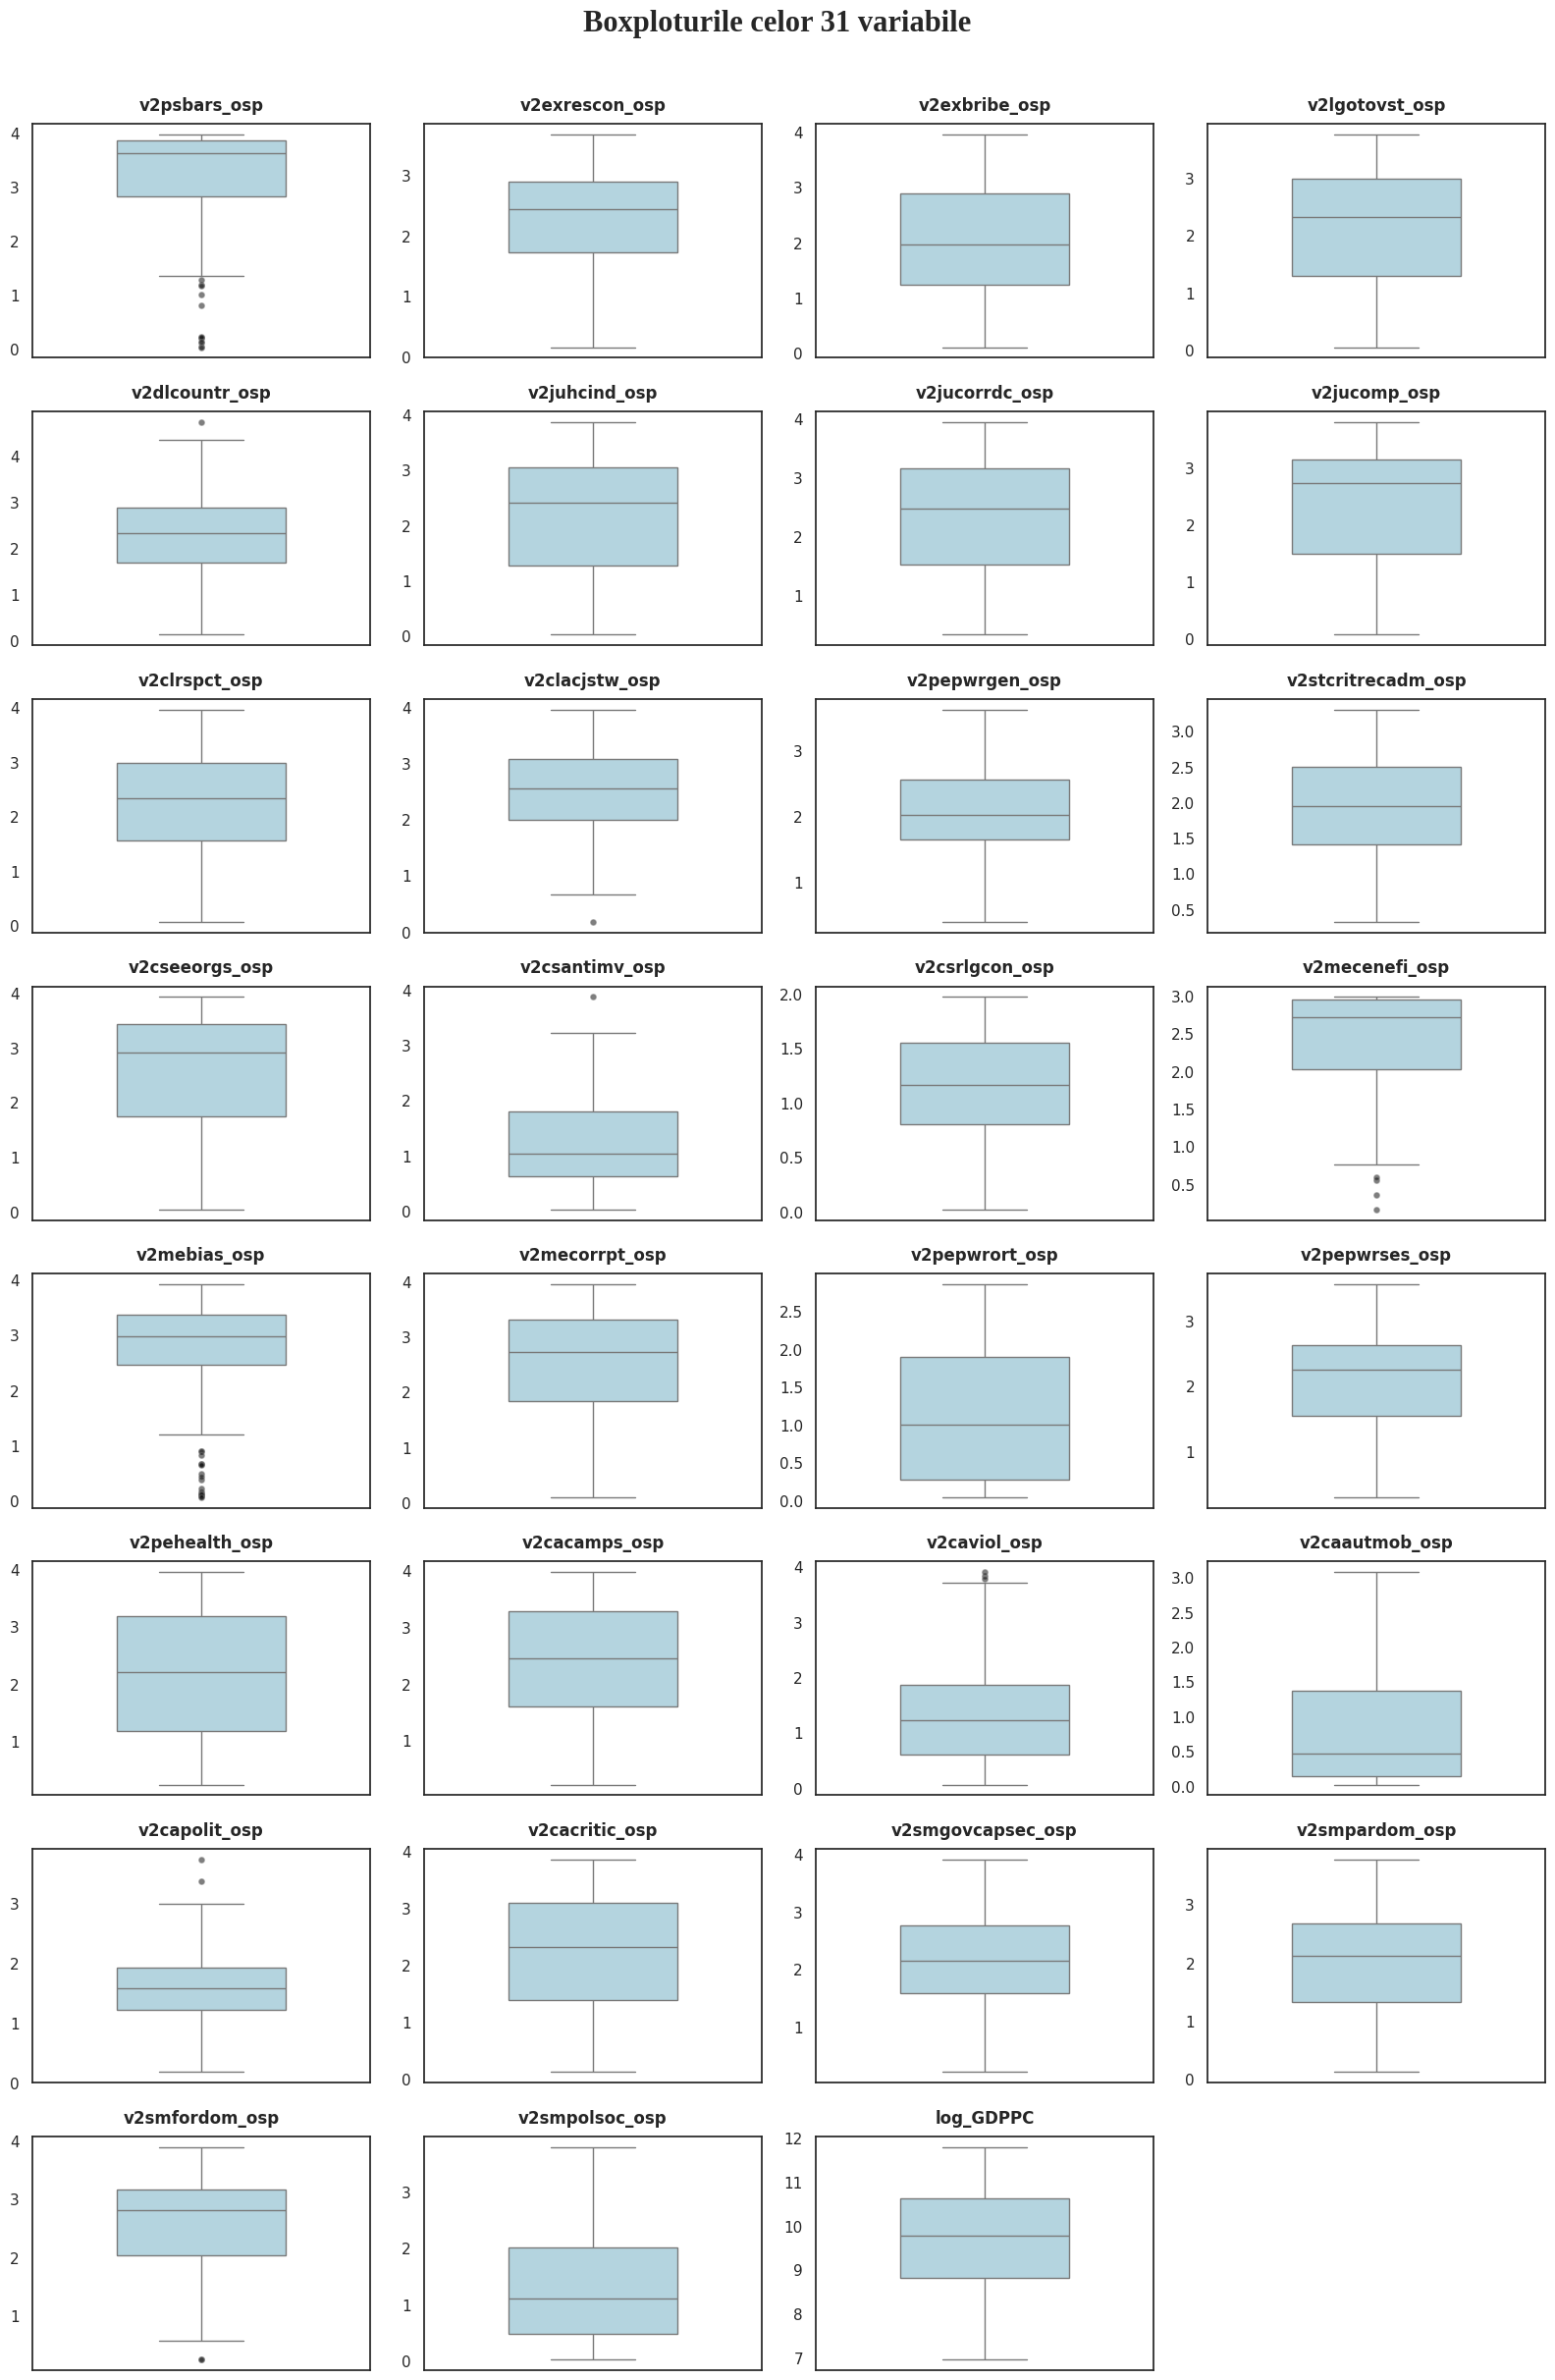

In [ ]:

sns.set_theme(style="white")

variabile_vdem = list(df.columns[3:34])

randuri = 8
coloane = 4

fig, axes = plt.subplots(nrows=randuri, ncols=coloane, figsize=(16, 24))
axes = axes.flatten() # transf in lista

# 31 de boxplots
for i in range(len(variabile_vdem)):
    sns.boxplot(
        data=df,
        y=variabile_vdem[i],
        ax=axes[i],
        color="lightblue",
        width=0.5,
        fliersize=4,         #outliers
        flierprops=dict(marker='o', markerfacecolor='black', alpha=0.5)
    )

    axes[i].set_title(variabile_vdem[i], fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")

# ascund ultimul patrat gol
for j in range(len(variabile_vdem), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxploturile celor 31 variabile",
             fontsize=22, fontname="Liberation Serif",fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig("anexa_toate_boxploturile.png", dpi=300, bbox_inches='tight')

plt.show()

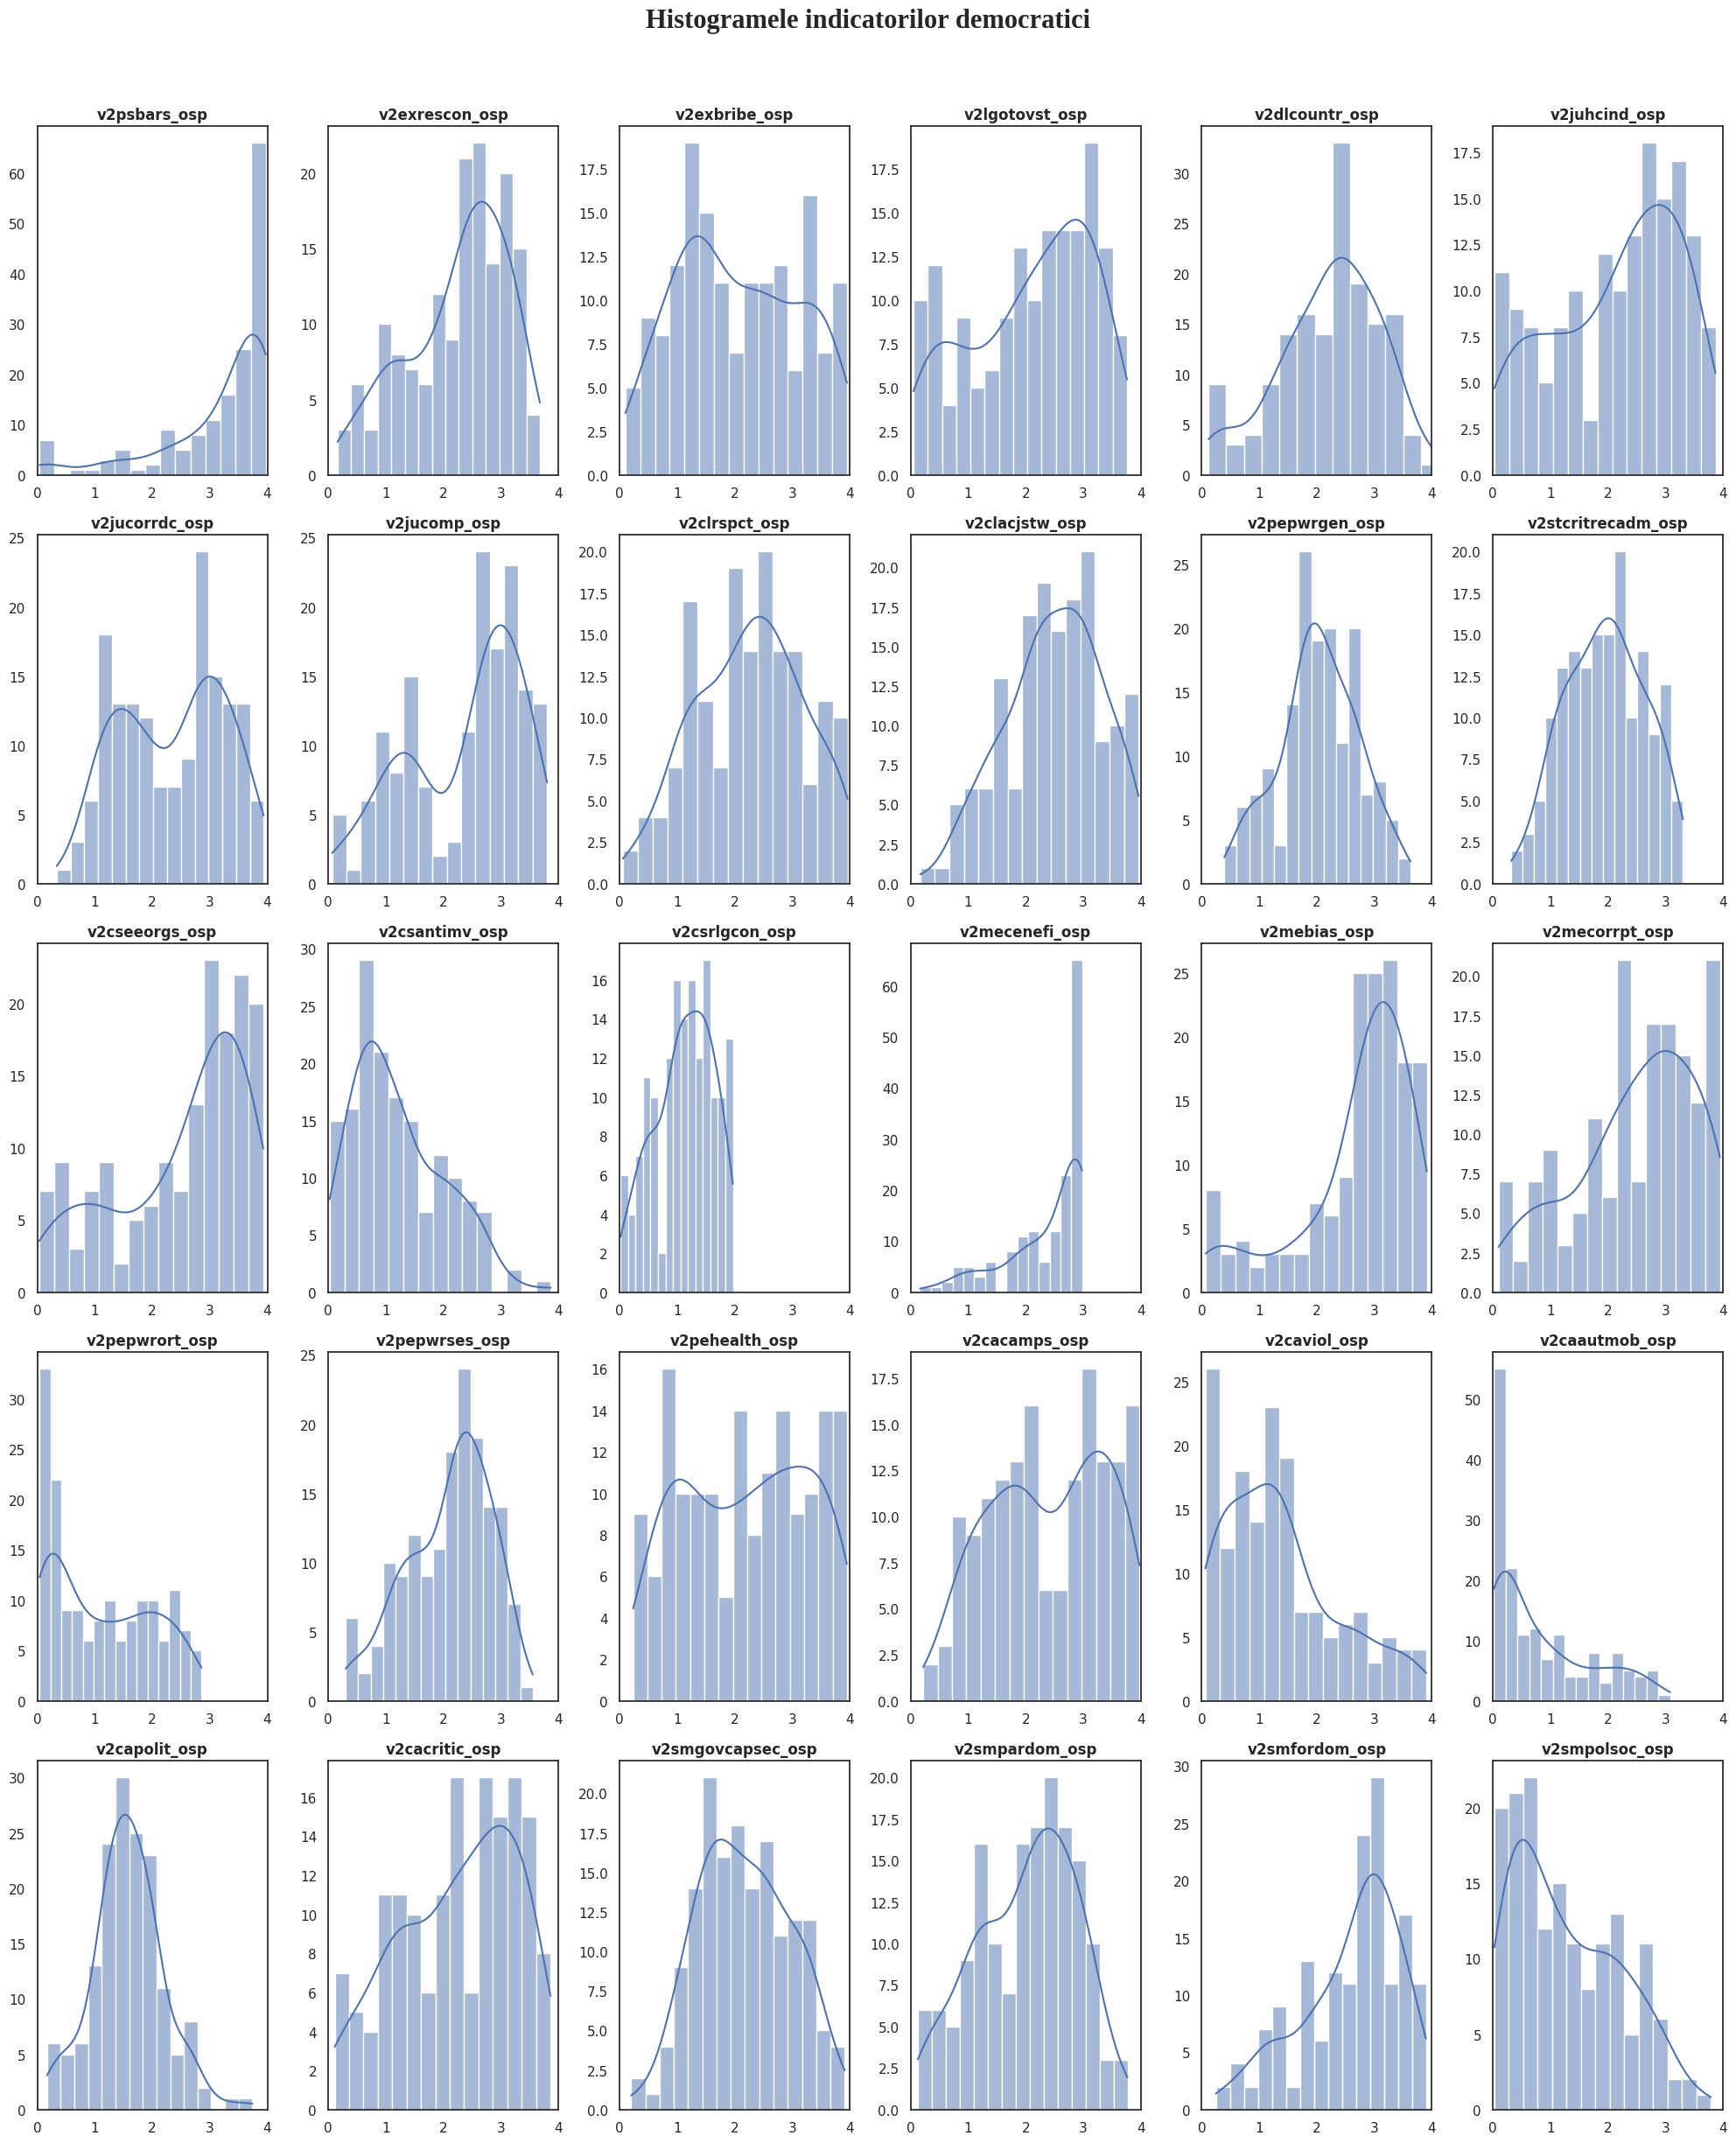

In [ ]:
sns.set_theme(style="white")
df1 = df.iloc[:,:-1]
coloane_30 = df1.iloc[:,3:].columns.tolist()
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20, 24))

axes = axes.flatten()

for i, variabila in enumerate(coloane_30):
    sns.histplot(
        data=df,
        x=variabila,
        bins=15,
        kde=True,
        color="#4c72b0",
        ax=axes[i]
    )

    axes[i].set_title(variabila, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xlim(0, 4)

for j in range(len(coloane_30), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Histogramele indicatorilor democratici",fontname="Liberation Serif", fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("toate_histogramele_vdem.png", dpi=300, bbox_inches='tight')
plt.show()

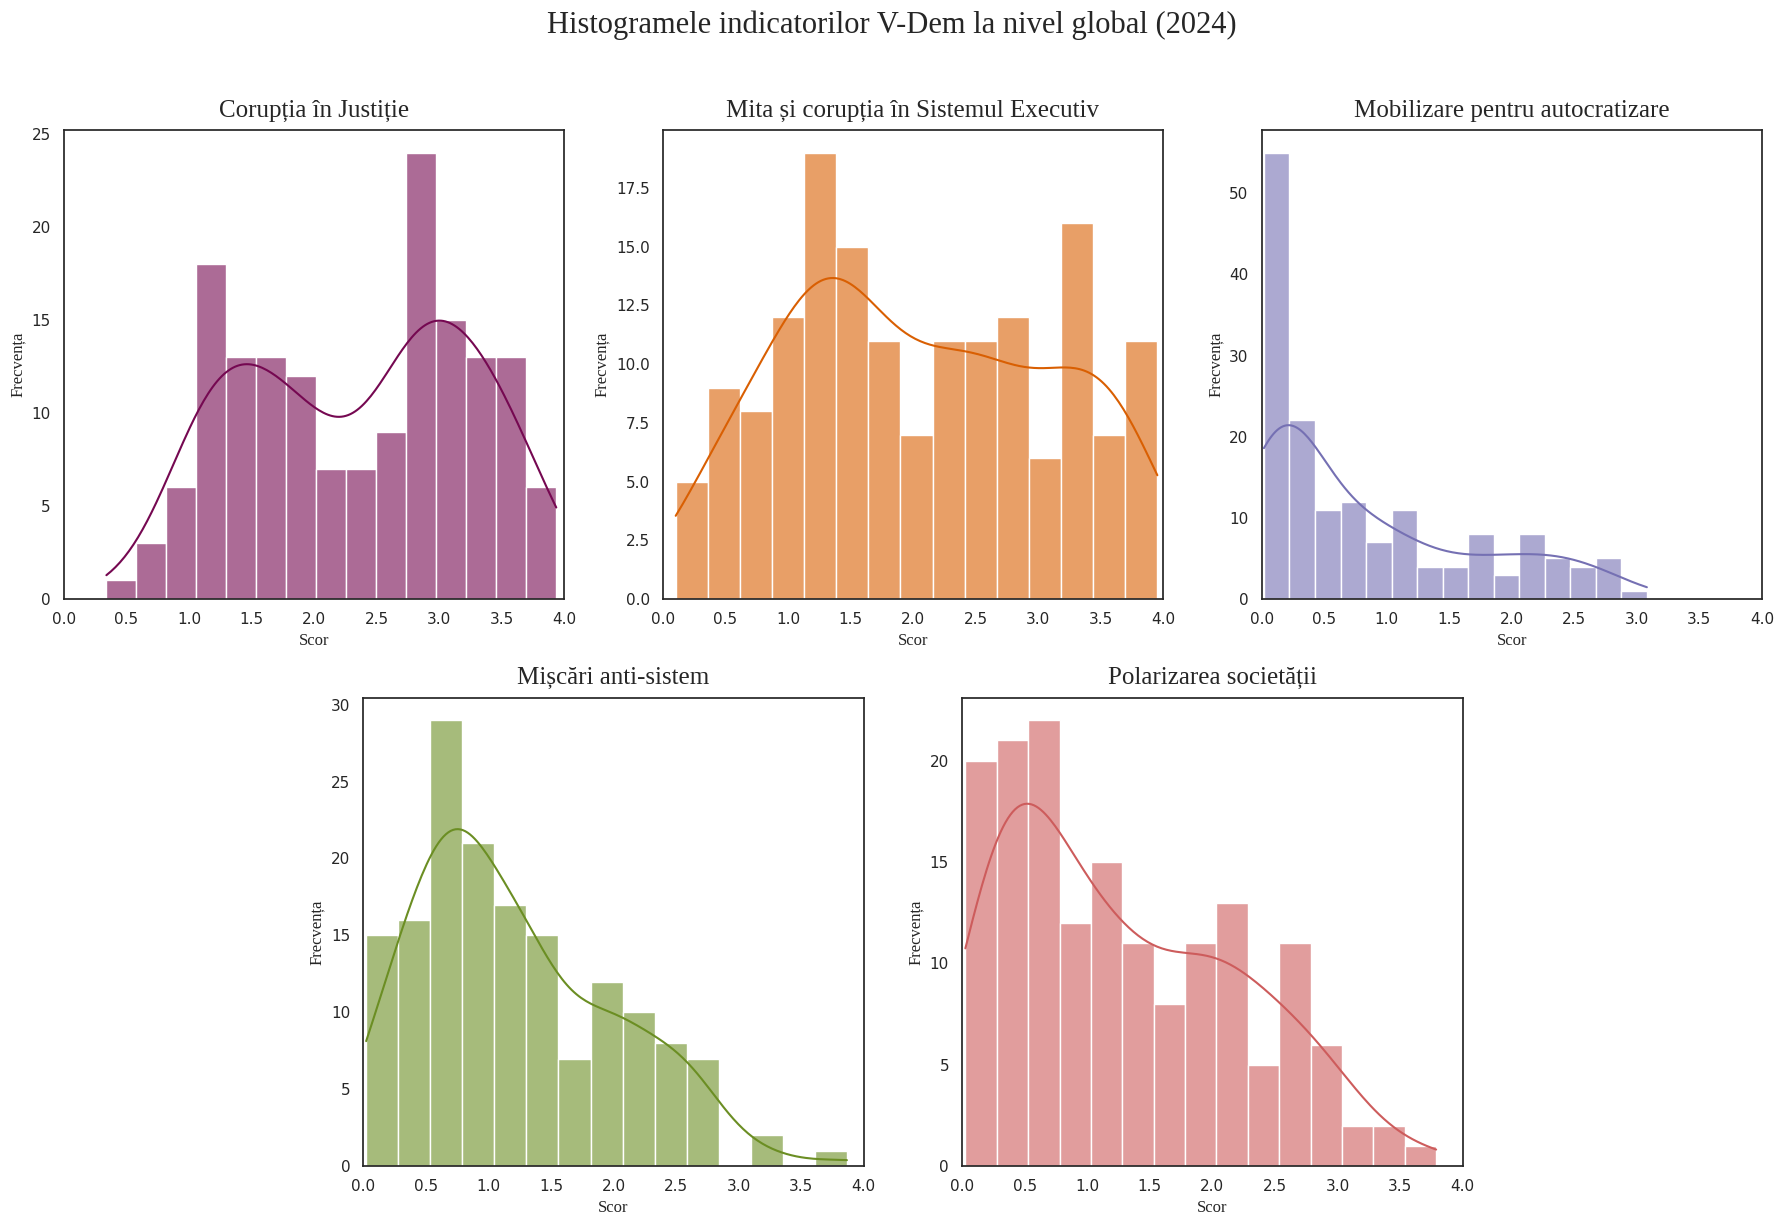

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

sns.set_theme(style="white")

# 1. Variables and Titles
variabile_alese = [
    'v2jucorrdc_osp', # coruptia in justitie
    'v2exbribe_osp', # mita si coruptia in sist exec
    'v2caautmob_osp', #mobilizare pentru autocratizare
    'v2csantimv_osp', # anti sistem
    'v2smpolsoc_osp' #polarizarea societatii
]

nume_titluri = [
    "Corupția în Justiție",
    "Mita și corupția în Sistemul Executiv",
    "Mobilizare pentru autocratizare",
    "Mișcări anti-sistem",
    "Polarizarea societății"
]

# 3 grafice deasupra, 2 dedesubt
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 6, figure=fig)

# define positions: (row, column_span)
# first row: 3 plots, each taking 2 columns
# second row: 2 plots, each taking 2 columns, shifted by 1 to center
ax_positions = [
    gs[0, 0:2], gs[0, 2:4], gs[0, 4:6],
    gs[1, 1:3], gs[1, 3:5]
]

culori = ["#750851", "#d95f02", "#7570b3", "olivedrab", "indianred"]

for i in range(len(variabile_alese)):
    ax = fig.add_subplot(ax_positions[i])
    sns.histplot(
        data=df,
        x=variabile_alese[i],
        bins=15,
        kde=True,
        color=culori[i],
        alpha=0.6,
        ax=ax
    )

    ax.set_title(nume_titluri[i], fontsize=18, fontname="Liberation Serif", pad=10)
    ax.set_xlabel("Scor", fontname="Liberation Serif", fontsize=12)
    ax.set_ylabel("Frecvența", fontname="Liberation Serif", fontsize=12)
    ax.set_xlim(0, 4)

plt.suptitle("Histogramele indicatorilor V-Dem la nivel global (2024)", fontname="Liberation Serif", fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig("histograme_vdem_centered.png", dpi=300, bbox_inches='tight')
plt.show()

## Analiza frecventelor pe histograme

In [ ]:
print("Pentru Polarizarea societatii:")
print(f"Nr tari deasupra pragului: {(df['v2smpolsoc_osp'] > 2).sum()}")
print(f"Nr tari sub prag: {(df['v2smpolsoc_osp'] <= 2).sum()}","\n")

print("Pentru Mobilizare pentru autocratizare:")
print(f"Nr tari cu valori intre 1 si 3: {((df['v2caautmob_osp'] > 1) & (df['v2caautmob_osp'] <= 3)).sum()}","\n")

# v2csantimv_osp
print("Pentru Miscari anti-sistem:")
print(f"Nr tari cu valori peste 2: {(df['v2csantimv_osp'] > 2).sum()}", "\n")

#v2cacamps_osp
print("Pentru Polarizare politica:")
print(f"Nr tari cu valori peste 2.5: {(df['v2cacamps_osp'] > 2.5).sum()}", "\n")


#v2spmardom_osp
print("Pentru Propaganda partidelor pe social media")
print(f"Nr tari cu valori sub 2: {(df['v2smpardom_osp'] < 2).sum()}", "\n")

#v2smfordom_osp
print("Pentru Propaganda statelor straine")
print(f"Nr tari cu valori sub 2.5: {(df['v2smfordom_osp'] < 2.5).sum()}")



Pentru Polarizarea societatii:
Nr tari deasupra pragului: 42
Nr tari sub prag: 118 

Pentru Mobilizare pentru autocratizare:
Nr tari cu valori intre 1 si 3: 53 

Pentru Miscari anti-sistem:
Nr tari cu valori peste 2: 31 

Pentru Polarizare politica:
Nr tari cu valori peste 2.5: 78 

Pentru Propaganda partidelor pe social media
Nr tari cu valori sub 2: 69 

Pentru Propaganda statelor straine
Nr tari cu valori sub 2.5: 59


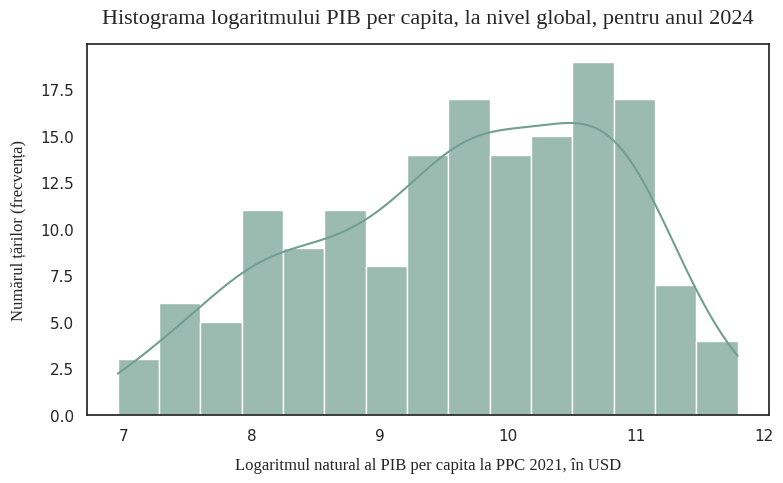

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='log_GDPPC',
    bins=15,
    kde=True,
    color="#719f91",
    alpha=0.7
)

plt.title("Histograma logaritmului PIB per capita, la nivel global, pentru anul 2024",fontname="Liberation Serif", fontsize=16, pad=15)
plt.xlabel("Logaritmul natural al PIB per capita la PPC 2021, în USD", fontsize=12, labelpad=10, fontname="Liberation Serif")
plt.ylabel("Numărul țărilor (frecvența)",fontname="Liberation Serif", fontsize=12, labelpad=10)
#plt.xlim(left=0)
plt.tight_layout()

plt.savefig("histograma_gdppc.png", dpi=300, bbox_inches='tight')

plt.show()

### Histograme V-Dem 2

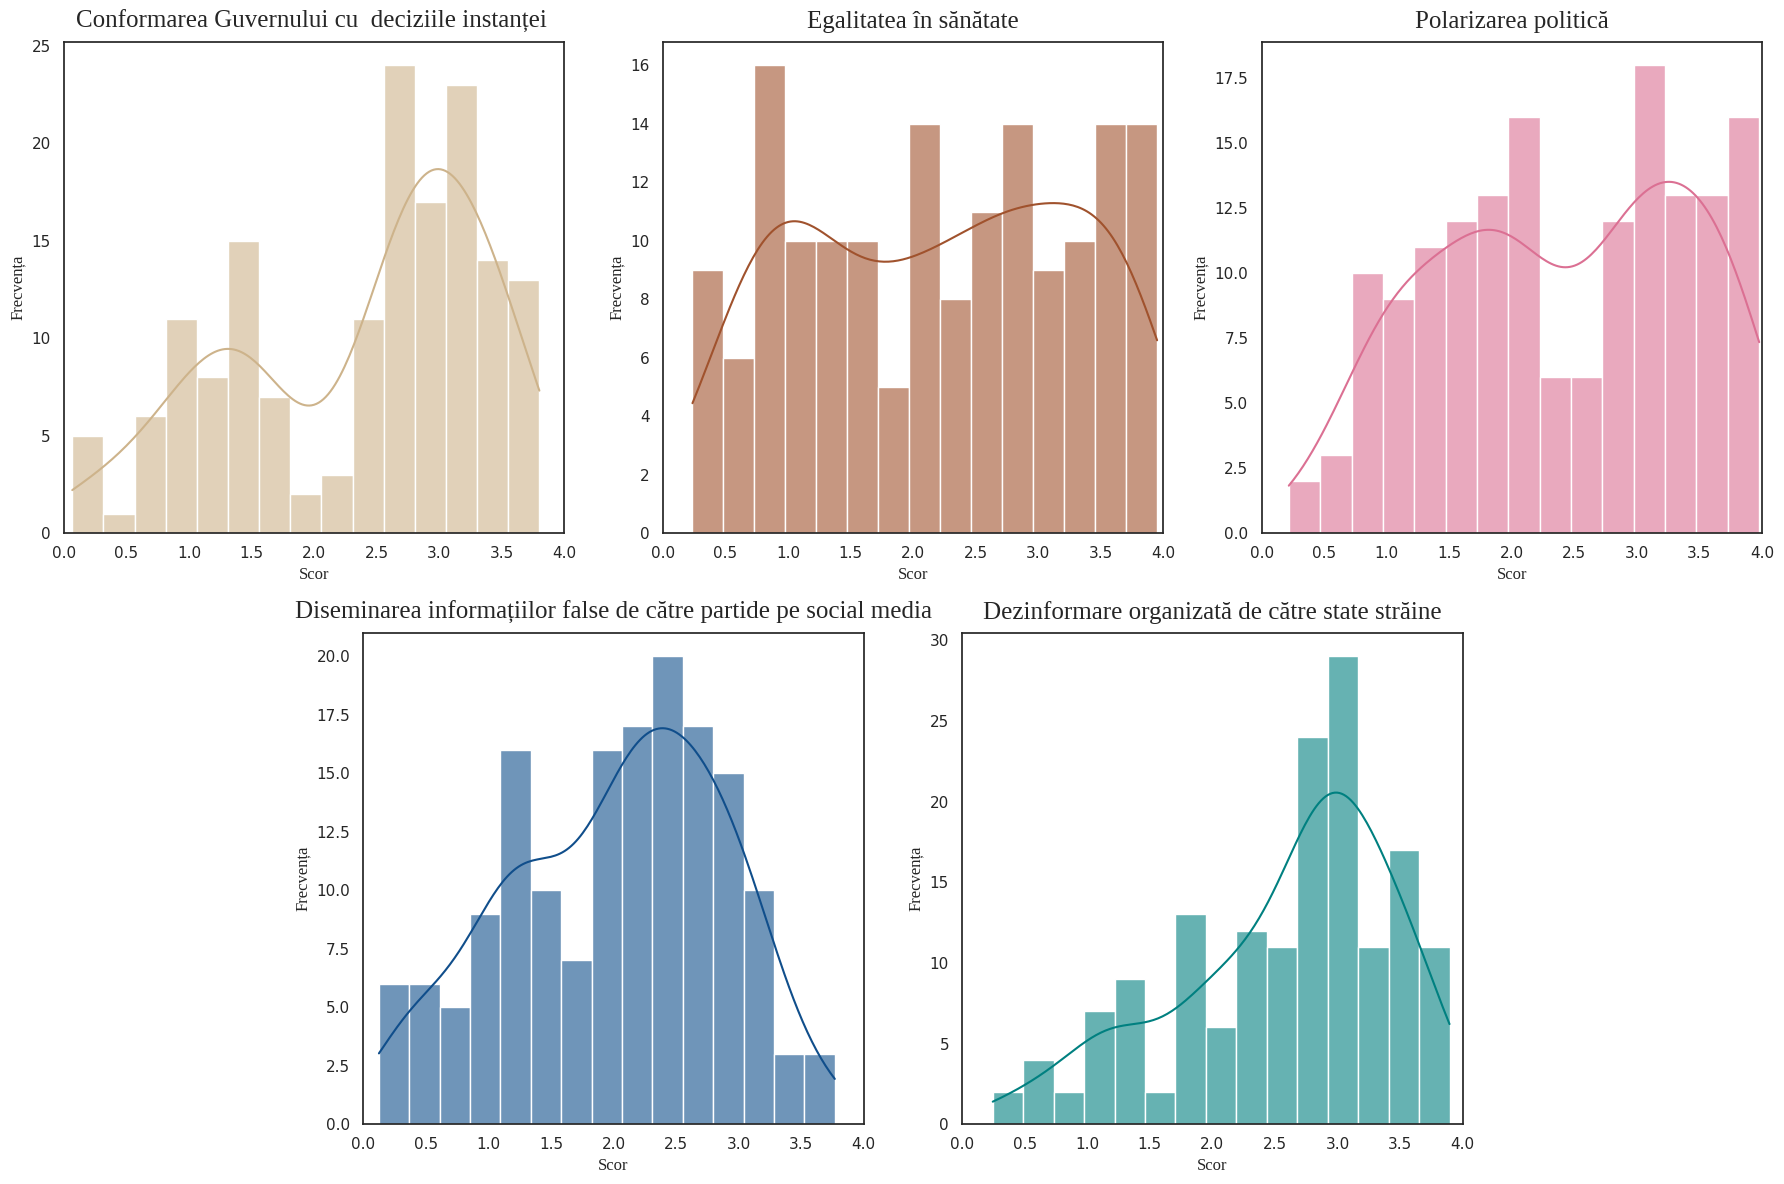

In [ ]:
sns.set_theme(style="white")

variabile_alese = [
    'v2jucomp_osp',
    'v2pehealth_osp',
    'v2cacamps_osp',
    'v2smpardom_osp',
    'v2smfordom_osp'
]

nume_titluri = [
    "Conformarea Guvernului cu  deciziile instanței ",
    "Egalitatea în sănătate",
    "Polarizarea politică",
    "Diseminarea informațiilor false de către partide pe social media",
    "Dezinformare organizată de către state străine"
]

# 3 grafice deasupra, 2 dedesubt
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 6, figure=fig)

# define positions: (row, column_span)
# first row: 3 plots, each taking 2 columns
# second row: 2 plots, each taking 2 columns, shifted by 1 to center
ax_positions = [
    gs[0, 0:2], gs[0, 2:4], gs[0, 4:6],
    gs[1, 1:3], gs[1, 3:5]
]

culori = ["#cdb38b", "sienna", "palevioletred", "#104e8b", "teal"]

for i in range(len(variabile_alese)):
    ax = fig.add_subplot(ax_positions[i])
    sns.histplot(
        data=df,
        x=variabile_alese[i],
        bins=15,
        kde=True,
        color=culori[i],
        alpha=0.6,
        ax=ax
    )

    ax.set_title(nume_titluri[i], fontsize=18, fontname="Liberation Serif", pad=10)
    ax.set_xlabel("Scor", fontname="Liberation Serif", fontsize=12)
    ax.set_ylabel("Frecvența", fontname="Liberation Serif", fontsize=12)
    ax.set_xlim(0, 4)

plt.tight_layout()
plt.savefig("histograme_vdem_3.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FA.csv")
df.drop(df.columns[0:3], axis=1)


,v2psbars_osp,v2exrescon_osp,v2exbribe_osp,v2lgotovst_osp,v2dlcountr_osp,v2juhcind_osp,v2jucorrdc_osp,v2jucomp_osp,v2clrspct_osp,v2clacjstw_osp,...,v2cacamps_osp,v2caviol_osp,v2caautmob_osp,v2capolit_osp,v2cacritic_osp,v2smgovcapsec_osp,v2smpardom_osp,v2smfordom_osp,v2smpolsoc_osp,GDPPC
0,3.541,1.726,1.448,1.015,1.344,2.261,2.499,1.162,1.733,1.634,...,3.788,3.320,0.615,1.403,2.829,2.180,0.816,2.981,0.332,22039.628702
1,3.873,3.141,2.697,2.359,2.435,2.675,3.372,3.152,2.559,3.192,...,2.049,1.436,0.096,2.103,1.346,1.565,2.447,3.030,1.187,19179.101832
2,3.960,3.202,3.948,3.688,3.246,3.753,3.639,3.658,3.738,3.749,...,1.715,0.620,0.018,2.002,3.418,3.132,3.192,2.786,1.751,62978.939046
3,3.947,3.677,3.846,3.250,3.755,3.420,3.526,3.685,3.919,3.880,...,1.023,0.137,0.043,2.618,2.698,3.051,2.994,3.896,0.604,82286.180190
4,3.914,2.352,1.032,3.075,2.487,3.001,1.239,3.096,1.145,2.750,...,1.861,1.857,0.041,2.529,3.632,1.639,2.093,3.460,0.446,7055.624960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,3.900,2.047,2.268,2.188,1.598,3.020,2.745,3.277,2.292,3.187,...,3.173,0.847,1.107,1.500,2.949,1.819,1.864,2.339,0.044,40319.054723
156,3.922,3.292,3.440,3.308,3.320,2.360,3.246,2.752,3.015,3.619,...,3.855,0.906,0.594,1.580,3.141,1.663,1.313,3.072,0.263,48648.907883
157,3.741,2.390,1.422,1.865,2.295,2.919,2.612,3.143,2.427,3.041,...,1.516,0.471,0.047,1.389,3.078,0.805,3.352,3.566,2.572,2353.248082
158,0.138,3.112,3.382,0.824,0.634,0.764,3.313,0.591,2.595,2.109,...,1.067,0.069,0.088,1.213,0.764,3.297,2.102,1.445,3.378,69701.804798


# Export fisier

In [ ]:
df.describe()
tabel_stat = df.describe().T

tabel_stat = tabel_stat.round(3)

# export
tabel_stat.to_excel("Statistici_descriptive.xlsx")